# Prerequisites

- Technical
  - Python programming skills
  - Numpy skills
  - Basic text preprocessing skills: lowercasing, tokenization, stop word removal, stemming...

- Theoretical
  - Basic linear algebra
  - Term frequency (TF) & Document frequency (DF)
  - Inverse document frequency (IDF)

# Introduction

## 1. What is TF-IDF?

**TF-IDF** is a statistical metric used to evaluate the importance of a term to a document in a corpus (collection of documents). It identifies important terms by multiplying two values: $TF$ which is how often a word appears in a text and $IDF$ the rarity of the term across the documents.

## 2. What problem does TF-IDF solve?

- **Penalizes overly common words:** frequent words (e.g. stop words) that appear frequently in the majority of documents and carry no unique information. **IDF** gives these words a lower weight.
- **Identifies true document topics:** By filtering out commond words, it isolates terms that are frequent in a specific document but rare accross the entire corpus.
- **Normalizes for document length:** TF-IDF divides term occurences by the total words in the document (Term Frequency), making documents of varying lengths directly comparable.

## 3. Real world applications

- **Search engines and Information Retrieval:** Ranking documents (e.g. web pages) by matching query keywords to relevant documents.
- **Keyword extraction:** Automatically identifies core topics and tags for articles or blogs.
- **Spam filtering:** Identigying malicious emails by scoring high-frequency trigger words.
- **Document organisation:** Grouping similar files, papers, customer support tickets into buckets.
- ...

## 4. When vs When not to use

| Use TF-IDF when | Avoid TF-IDF when |
| --- | --- |
| Keyword-Matching: Building fast, exact-match search or information retrieval systems. | Semantic Meaning Matters: You need to capture synonyms, context, or conceptual relationships. (Use Embeddings/Transformers) |
| Simple Baselines: You want an interpretable, low-compute text representation that requires no deep learning. | Word Order Matters: Sequence, grammar, or negation changes the meaning (e.g., "not good"). TF-IDF treats text as an unordered bag of words. |
| Traditional ML: Feeding text features into sparse-friendly models like Naive Bayes or Linear SVMs. | New Vocabulary (OOV): Your data frequently introduces brand new terms missing from the training corpus. (Use Subword Tokenizers) |

# TF-IDF Algorithm

## 1. Mathematical Formulation

### Term Frequency (TF)

The **term requency** refres to the number of occurences of a word in a document:

$$tf(t, d) = \frac{f_{t,d}}{\sum_{t'∈d}{f_{t', d}}}$$

- $f_{t,d}$: raw count of a term in a document.
- $\sum_{t'∈d}f_{t', d}$: the denominator is the total number of terms in document $d$.


##### Other TF variants

| Variant | tf weight |
| --- | --- |
| binary | $$0, 1$$ |
| raw count | $$f_{t, d}$$ |
| term frequency | $$\frac{f_{t, d}}{\sum_{t'∈d}{f_{t', d}}}$$ |
| log normalization | $$log(1 + f_{t, d})$$ |
| double normalization | $$0.5 + 0.5\cdot\frac{f_{t, d}}{max_{t'\in d}f_{t', d}}$$ |

### Inverse Document Frequency (IDF)

The **Inverse document frequency** measures how much information a term provides, in other words how rare it is across the documents:

$$IDF(t, D) = ln(\frac{N}{n_t})$$

- $D$: the set of all documents in the corpus
- $N or |D|$: cardinality of the corpus which is the total number of documents in the corpus.
- $n_t$: number of documents where the term $t$ appears.

#### Other IDF variants

| Variant | tf weight |
| --- | --- |
| unary | 1 |
| IDF | $$ln(\frac{N}{n_t})$$ |
| smooth IDF | $$ln(\frac{N}{1 + n_t}) + 1$$ |
| IDF max | $$ln(\frac{max_{t'∈d}n_{t'}}{1 + n_t})$$ |
| BM25 IDF | $$ln[\frac{N - n_t + 0.5}{n_t + 0.5} + 1]$$ |
| Probabilistic IDF | $$ln(\frac{N - n_t}{n_t})$$ |


### TF-IDF

The TF-IDF formula is as follows:

$$tfidf(t, d, D) = tf(t, d) \cdot idf(t, D)$$

Since it is just the product between $tf$ and $IDF$ then:

- **High TF-IDF score:** The term appears frequently in the document but rarely across the corpus. So it is an important and descriptive word for the document.
- **Low/Zero TF-IDF:** The term either appears rarely in the document, or it is a highly frequent word across the corpus (e.g. stop words).

In [1]:
import kagglehub

path = kagglehub.dataset_download("dmaso01dsta/cisi-a-dataset-for-information-retrieval")

print("Path to dataset files:", path)

100%|██████████| 759k/759k [00:00<00:00, 61.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/dmaso01dsta/cisi-a-dataset-for-information-retrieval/versions/1


In [2]:
import pandas as pd

def load_cisi_all(file_path: str):
    documents = []
    current_doc = {}
    current_key = None

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            stripped = line.strip()
            if not stripped: continue

            if line.startswith((".I", ".T", ".A", ".W", ".X")):
                current_key = line[:2]
                if current_key == ".I":
                    if current_doc:
                        documents.append(current_doc)
                    current_doc = {'id': int(line.split()[1]), 'author': "", 'abstract': ""}
                continue

            if current_key == ".T":
                current_doc['abstract'] += stripped
            elif current_key == ".A":
                current_doc['author'] += " " + stripped
            elif current_key == ".W":
                current_doc['abstract'] += " " + stripped

    if current_doc:
        documents.append(current_doc)

    return pd.DataFrame(documents)

In [3]:
cisi_all_df = load_cisi_all(path + "/CISI.ALL")

cisi_all_df['abstract'].to_list()[66]

'The Use of Simulation in Studying Information Storage and Retrieval Systems Previous applications of simulation to information storage and retrieval systems (ISRS) have been overly restrictive in their scope and have failed to consider the environment within which such systems operate.. This paper considers the ISRS as a subsystem within a larger system which includes the users and the funders of the retrieval system.. The three components form a closed-loop information feedback system in which user response influences both the funding and operation of the ISRS as it attempts to satisfy user needs within a finite budget allocation.. Reward-cost theory provides the basis for describing user behavior.. An industrial dynamics model has been developed to simulate ISRS/user/funder behavior where a university departmental library is the ISRS component.. The results which such an analysis can produce are discussed..'

In [4]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.stem import SnowballStemmer
import numpy as np

class TFIdf:
  def __init__(self) -> None:
    self.vocab = []
    self._token_to_idx = {}
    self._idf = None
    self._tfidf_mat = None
    self._stemmer = SnowballStemmer('english')

  def tokenize(self, text: str) -> list[str]:
    text = text.lower()
    tokens = ["".join([c for c in t if c.isalnum()]) for t in text.split()]
    return [self._stemmer.stem(token) for token in tokens if token not in ENGLISH_STOP_WORDS]

  def fit(self, docs: list[str]) -> None:
    n_docs = len(docs)
    unique_toks = set(tok for doc in docs for tok in self.tokenize(doc))
    self.vocab = sorted(list(unique_toks))
    self._token_to_idx = {token: i for i, token in enumerate(self.vocab)}

    doc_freq = np.zeros(len(self.vocab))
    self._tfidf_mat = np.zeros((n_docs, len(self.vocab)))
    for i, doc in enumerate(docs):
      tokenized_doc = self.tokenize(doc)
      for term in set(tokenized_doc):
        doc_freq[self._token_to_idx[term]] += 1
        self._tfidf_mat[i][self._token_to_idx[term]] += tokenized_doc.count(term)

    self._tfidf_mat = np.log10(1 + self._tfidf_mat)
    self._idf = np.log10(n_docs / (1 + doc_freq))
    self._tfidf_mat *= self._idf

  def get_doc_vector(self, doc: str) -> np.array:
    tokenized_doc = self.tokenize(doc)

    tf = np.zeros(len(self.vocab))
    for term in tokenized_doc:
      if term in self.vocab:
        tf[self._token_to_idx[term]] += tokenized_doc.count(term)

    tf = np.log10(1 + tf)
    return tf * self._idf

  def top_n_docs(self, query: str, top_n=10) -> np.ndarray:
    q_v = self.get_doc_vector(query)
    magnitude_dot = np.linalg.norm(self._tfidf_mat, axis=1) * np.linalg.norm(q_v)
    scores = np.dot(self._tfidf_mat, q_v) / (magnitude_dot + 1e-9)

    return np.argsort(scores)[::-1][:top_n]

docs = cisi_all_df['abstract'].to_list()

model = TFIdf()
model.fit(docs)

query = "Information storage and retrieval systems"

top_docs = model.top_n_docs(query, top_n=5)
top_docs

array([ 253, 1052,  470,  134,  500])

In [8]:
cisi_all_df.iloc[top_docs]['abstract']

,abstract
253,Chemical Information Systems The purpose of a ...
1052,Methods of Information Handling This book is m...
470,"Information Storage and Retrieval:tools, eleme..."
134,Design of Information Systems and Services Thi...
500,Compilation of Thesauri for Use in Computer Sy...


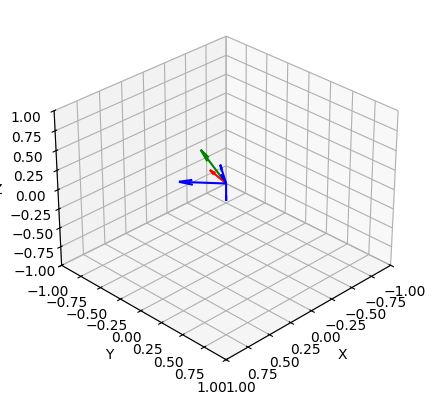

In [9]:
# Visualizing the similarity between the query (vector in green) and the most relevant
# documents to it (vectors in green (top 1) and in blue)
# The vector in red is the most similar document to our query
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=3)
q_v = model.get_doc_vector(query)
all_data = np.vstack([model._tfidf_mat, q_v])
reduced_data = pca.fit_transform(all_data)

reduced_mat = reduced_data[:-1]
reduced_q = reduced_data[-1]

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.quiver(-1, -1, -1, reduced_q[0], reduced_q[1], reduced_q[2], color='green', label='Query')
for doc_idx in top_docs:
  doc_vec = reduced_mat[doc_idx]
  ax.quiver(-1, -1, -1, doc_vec[0], doc_vec[1], doc_vec[2],
            color='red' if doc_idx == top_docs[0] else 'blue')

ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(-1, 1)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.view_init(azim=45)